In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "archive/mnist_png/training"   
TEST_DIR  = "archive/mnist_png/testing"    

IMG_SIZE = 28          # MNIST is natively 28x28; images are resized to this if not already
NOISE_FACTOR = 0.4     # standard deviation of the Gaussian noise added to pixel values

##  Loading and Preprocess the Dataset

.

In [2]:
def load_folder_dataset(root_dir, img_size=IMG_SIZE):
    
    images, labels = [], []
    class_names = sorted(os.listdir(root_dir), key=lambda x: int(x))

    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            try:
                img = Image.open(fpath).convert("L").resize((img_size, img_size))
            except Exception:
                continue  # skip unreadable / non-image files
            images.append(np.array(img, dtype=np.float32))
            labels.append(int(cls))

    images = np.array(images)
    labels = np.array(labels)
    images = images / 255.0
    images = images.reshape(-1, img_size, img_size, 1)
    return images, labels


x_train, y_train = load_folder_dataset(TRAIN_DIR)
x_test, y_test = load_folder_dataset(TEST_DIR)

print(f"Train set: {x_train.shape}, Test set: {x_test.shape}")
print(f"Pixel value range: [{x_train.min():.2f}, {x_train.max():.2f}]")


Train set: (60000, 28, 28, 1), Test set: (10000, 28, 28, 1)
Pixel value range: [0.00, 1.00]


## Added Artificial Noise


In [3]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)


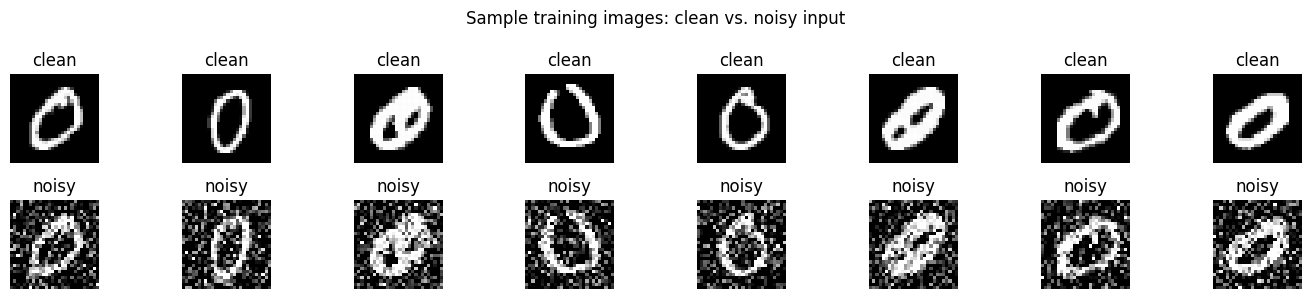

In [4]:

n = 8
plt.figure(figsize=(14, 3))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("clean")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("noisy")
    plt.axis("off")
plt.suptitle("Sample training images: clean vs. noisy input")
plt.tight_layout()
plt.show()


## Denoising Autoencoder

A small convolutional encoder-decoder for 28x28 grayscale digits:


In [5]:
def build_autoencoder(img_size=IMG_SIZE):
    inputs = keras.Input(shape=(img_size, img_size, 1))

    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)  # (7, 7, 16) bottleneck

    # Decoder
    x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(encoded)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    decoded = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = keras.Model(inputs, decoded, name="denoising_autoencoder")
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

autoencoder = build_autoencoder()
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training



In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

EPOCHS = 30
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/30
469/469 - 10s - 22ms/step - loss: 0.1941 - val_loss: 0.1117
Epoch 2/30
469/469 - 9s - 19ms/step - loss: 0.1074 - val_loss: 0.1023
Epoch 3/30
469/469 - 9s - 20ms/step - loss: 0.1018 - val_loss: 0.0992
Epoch 4/30
469/469 - 9s - 18ms/step - loss: 0.0994 - val_loss: 0.0975
Epoch 5/30
469/469 - 9s - 19ms/step - loss: 0.0979 - val_loss: 0.0963
Epoch 6/30
469/469 - 9s - 18ms/step - loss: 0.0968 - val_loss: 0.0953
Epoch 7/30
469/469 - 9s - 18ms/step - loss: 0.0958 - val_loss: 0.0944
Epoch 8/30
469/469 - 9s - 19ms/step - loss: 0.0949 - val_loss: 0.0936
Epoch 9/30
469/469 - 10s - 20ms/step - loss: 0.0942 - val_loss: 0.0929
Epoch 10/30
469/469 - 10s - 21ms/step - loss: 0.0936 - val_loss: 0.0924
Epoch 11/30
469/469 - 10s - 21ms/step - loss: 0.0931 - val_loss: 0.0920
Epoch 12/30
469/469 - 11s - 23ms/step - loss: 0.0927 - val_loss: 0.0917
Epoch 13/30
469/469 - 12s - 26ms/step - loss: 0.0924 - val_loss: 0.0914
Epoch 14/30
469/469 - 10s - 21ms/step - loss: 0.0921 - val_loss: 0.0913
Epoch 15

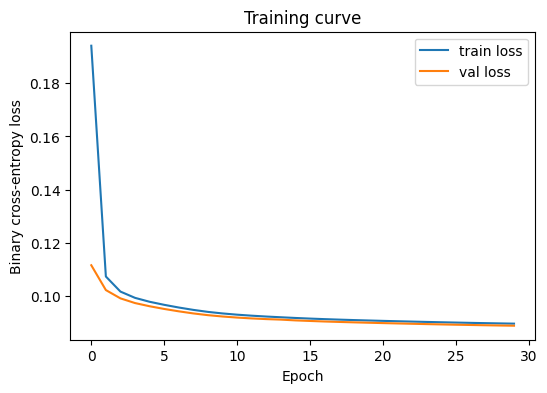

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training curve")
plt.legend()
plt.show()


##  Generated Denoised Outputs 



40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


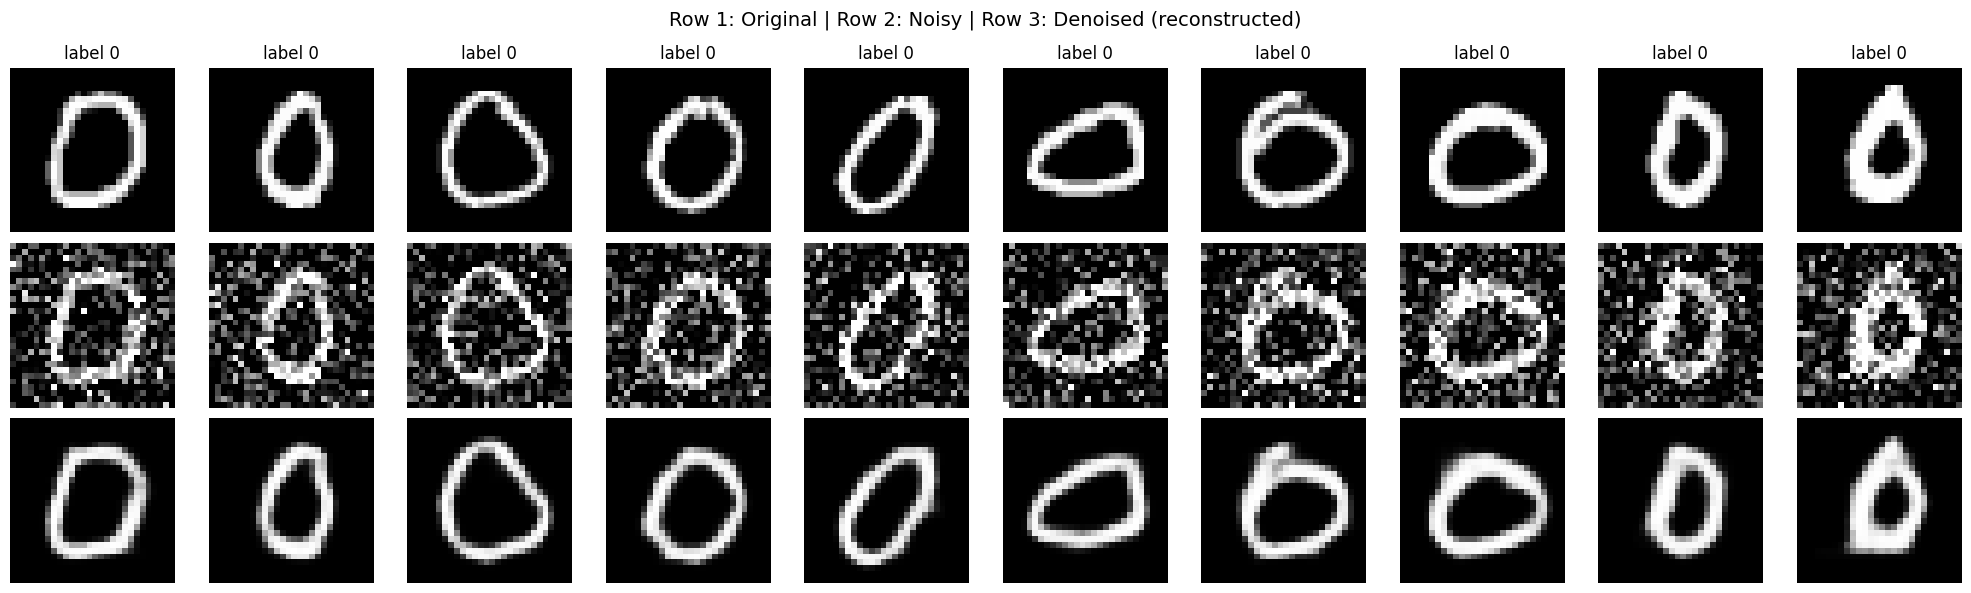

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy, batch_size=256)

n = 10  
plt.figure(figsize=(20, 6))
for i in range(n):
    
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("Original", fontsize=12)
    ax.set_title(f"label {y_test[i]}")

    # noisy 
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

    # reconstructed
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Row 1: Original | Row 2: Noisy | Row 3: Denoised (reconstructed)", fontsize=14)
plt.tight_layout()
plt.show()


### Quantitative evaluation

- **MSE (Mean Squared Error)** between images, lower is better.
- **PSNR (Peak Signal-to-Noise Ratio)** in dB, higher is better.

Computed both **noisy vs. clean** (the baseline, i.e. how corrupted the input was) and
**denoised vs. clean** (how well the autoencoder recovered the original), so the improvement
from denoising is explicit.

In [9]:
def mse(a, b):
    return np.mean((a - b) ** 2)

def psnr(a, b, max_val=1.0):
    m = mse(a, b)
    if m == 0:
        return float("inf")
    return 20 * np.log10(max_val) - 10 * np.log10(m)

mse_noisy = mse(x_test_noisy, x_test)
mse_denoised = mse(decoded_imgs, x_test)
psnr_noisy = psnr(x_test_noisy, x_test)
psnr_denoised = psnr(decoded_imgs, x_test)

print(f"{'Metric':<12}{'Noisy vs Clean':>18}{'Denoised vs Clean':>20}")
print(f"{'MSE':<12}{mse_noisy:>18.5f}{mse_denoised:>20.5f}")
print(f"{'PSNR (dB)':<12}{psnr_noisy:>18.2f}{psnr_denoised:>20.2f}")


Metric          Noisy vs Clean   Denoised vs Clean
MSE                    0.07957             0.00876
PSNR (dB)                10.99               20.57


## 6. Analysis and Observations


->The denoising autoencoder successfully reduced Gaussian noise while preserving the overall structure of the handwritten digits.

->The reconstructed images were significantly cleaner than the noisy inputs, although minor details were slightly blurred.

->The model converged smoothly during training, indicating effective learning of image features.
Overall, the autoencoder demonstrated good denoising performance on the MNIST dataset and produced visually improved outputs
